# Alura Store Latam — Análisis Comparativo de Tiendas

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

STORE_URLS = {
    "Tienda 1": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv",
    "Tienda 2": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv",
    "Tienda 3": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv",
    "Tienda 4": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv",
}

tiendas = {name: pd.read_csv(url) for name, url in STORE_URLS.items()}

tiendas["Tienda 1"].head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


---
## 1. Análisis de Facturación

In [18]:
ingresos = {name: df["Precio"].sum() for name, df in tiendas.items()}

for name, total in ingresos.items():
    print(f"Ingreso total {name}: ${total:,.0f}")

Ingreso total Tienda 1: $1,150,880,400
Ingreso total Tienda 2: $1,116,343,500
Ingreso total Tienda 3: $1,098,019,600
Ingreso total Tienda 4: $1,038,375,700


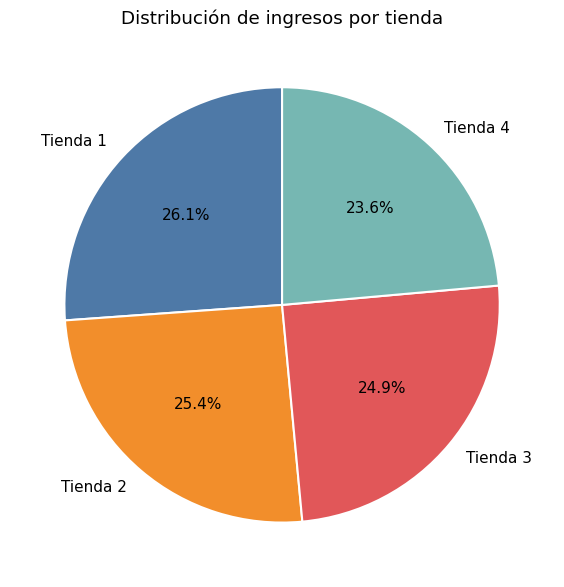

In [19]:
colors = ["#4e79a7", "#f28e2b", "#e15759", "#76b7b2"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    ingresos.values(),
    labels=ingresos.keys(),
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Distribución de ingresos por tienda")
plt.tight_layout()
plt.show()

---
## 2. Ventas por Categoría

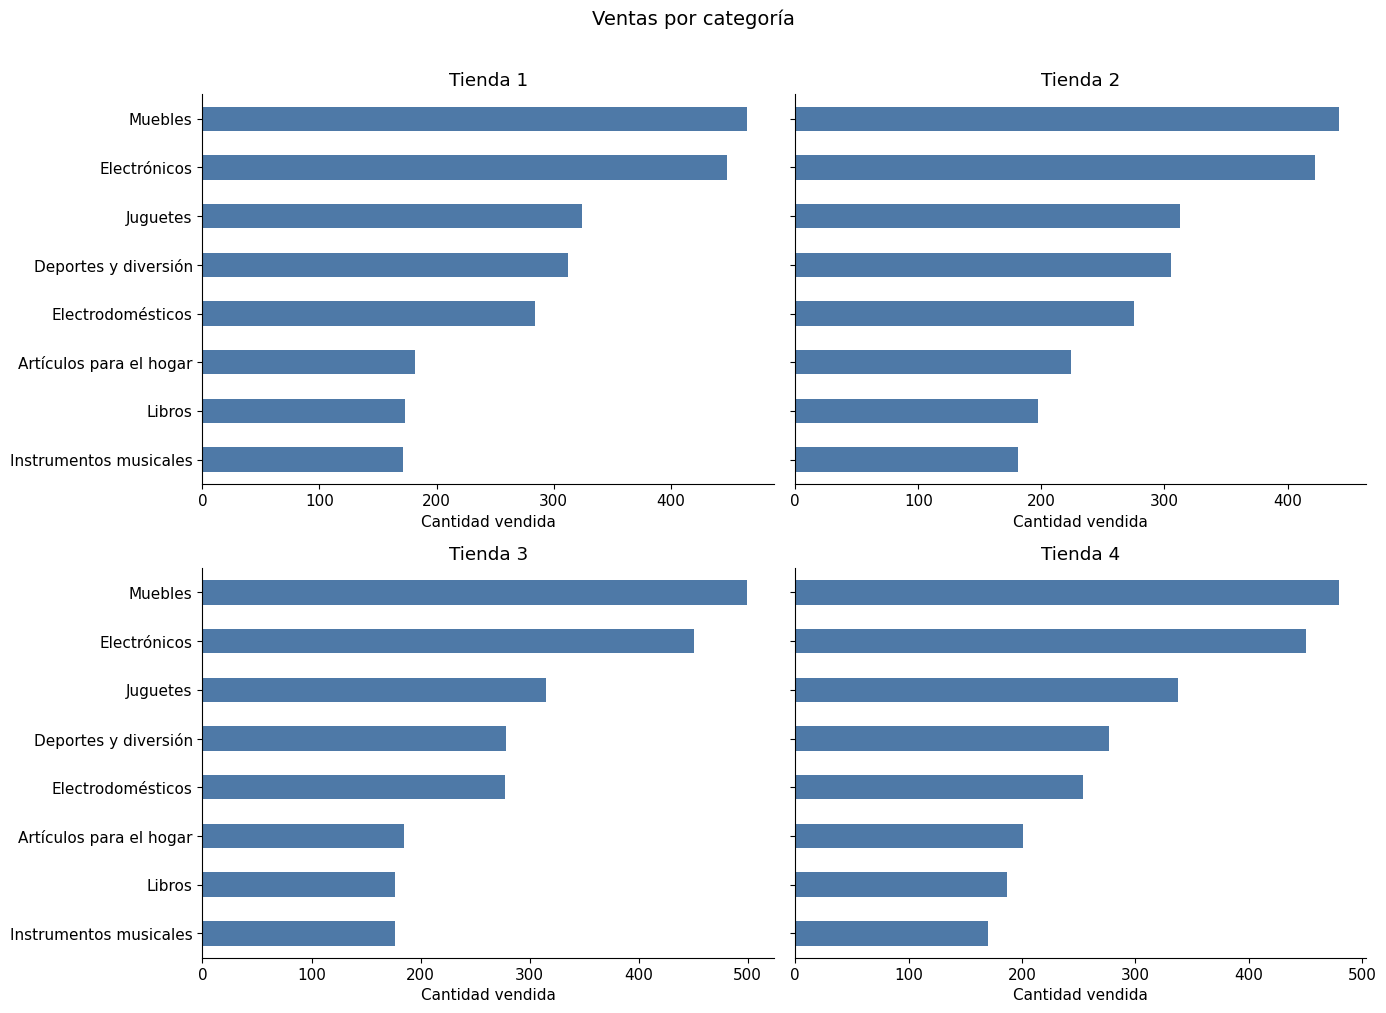

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

for ax, (name, df) in zip(axes.flat, tiendas.items()):
    ventas = (
        df.groupby("Categoría del Producto")["Producto"]
        .count()
        .sort_values(ascending=True)
    )
    ventas.plot.barh(ax=ax, color="#4e79a7")
    ax.set_title(name)
    ax.set_xlabel("Cantidad vendida")
    ax.set_ylabel("")

plt.suptitle("Ventas por categoría", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Calificación Promedio por Tienda

In [10]:
calificaciones = {name: df["Calificación"].mean() for name, df in tiendas.items()}

for name, rating in calificaciones.items():
    print(f"La calificación promedio por la {name} es: {rating:.2f}")

La calificación promedio por la Tienda 1 es: 3.98
La calificación promedio por la Tienda 2 es: 4.04
La calificación promedio por la Tienda 3 es: 4.05
La calificación promedio por la Tienda 4 es: 4.00


In [ ]:
fig, ax = plt.subplots()

bars = ax.bar(calificaciones.keys(), calificaciones.values(), color="#59a14f", width=0.5)
ax.bar_label(bars, fmt="%.2f", padding=4)
ax.set_ylabel("Calificación promedio")
ax.set_ylim(3.9, 4.1)
ax.set_title("Calificación promedio por tienda")
plt.tight_layout()
plt.show()

---
## 4. Productos Más y Menos Vendidos

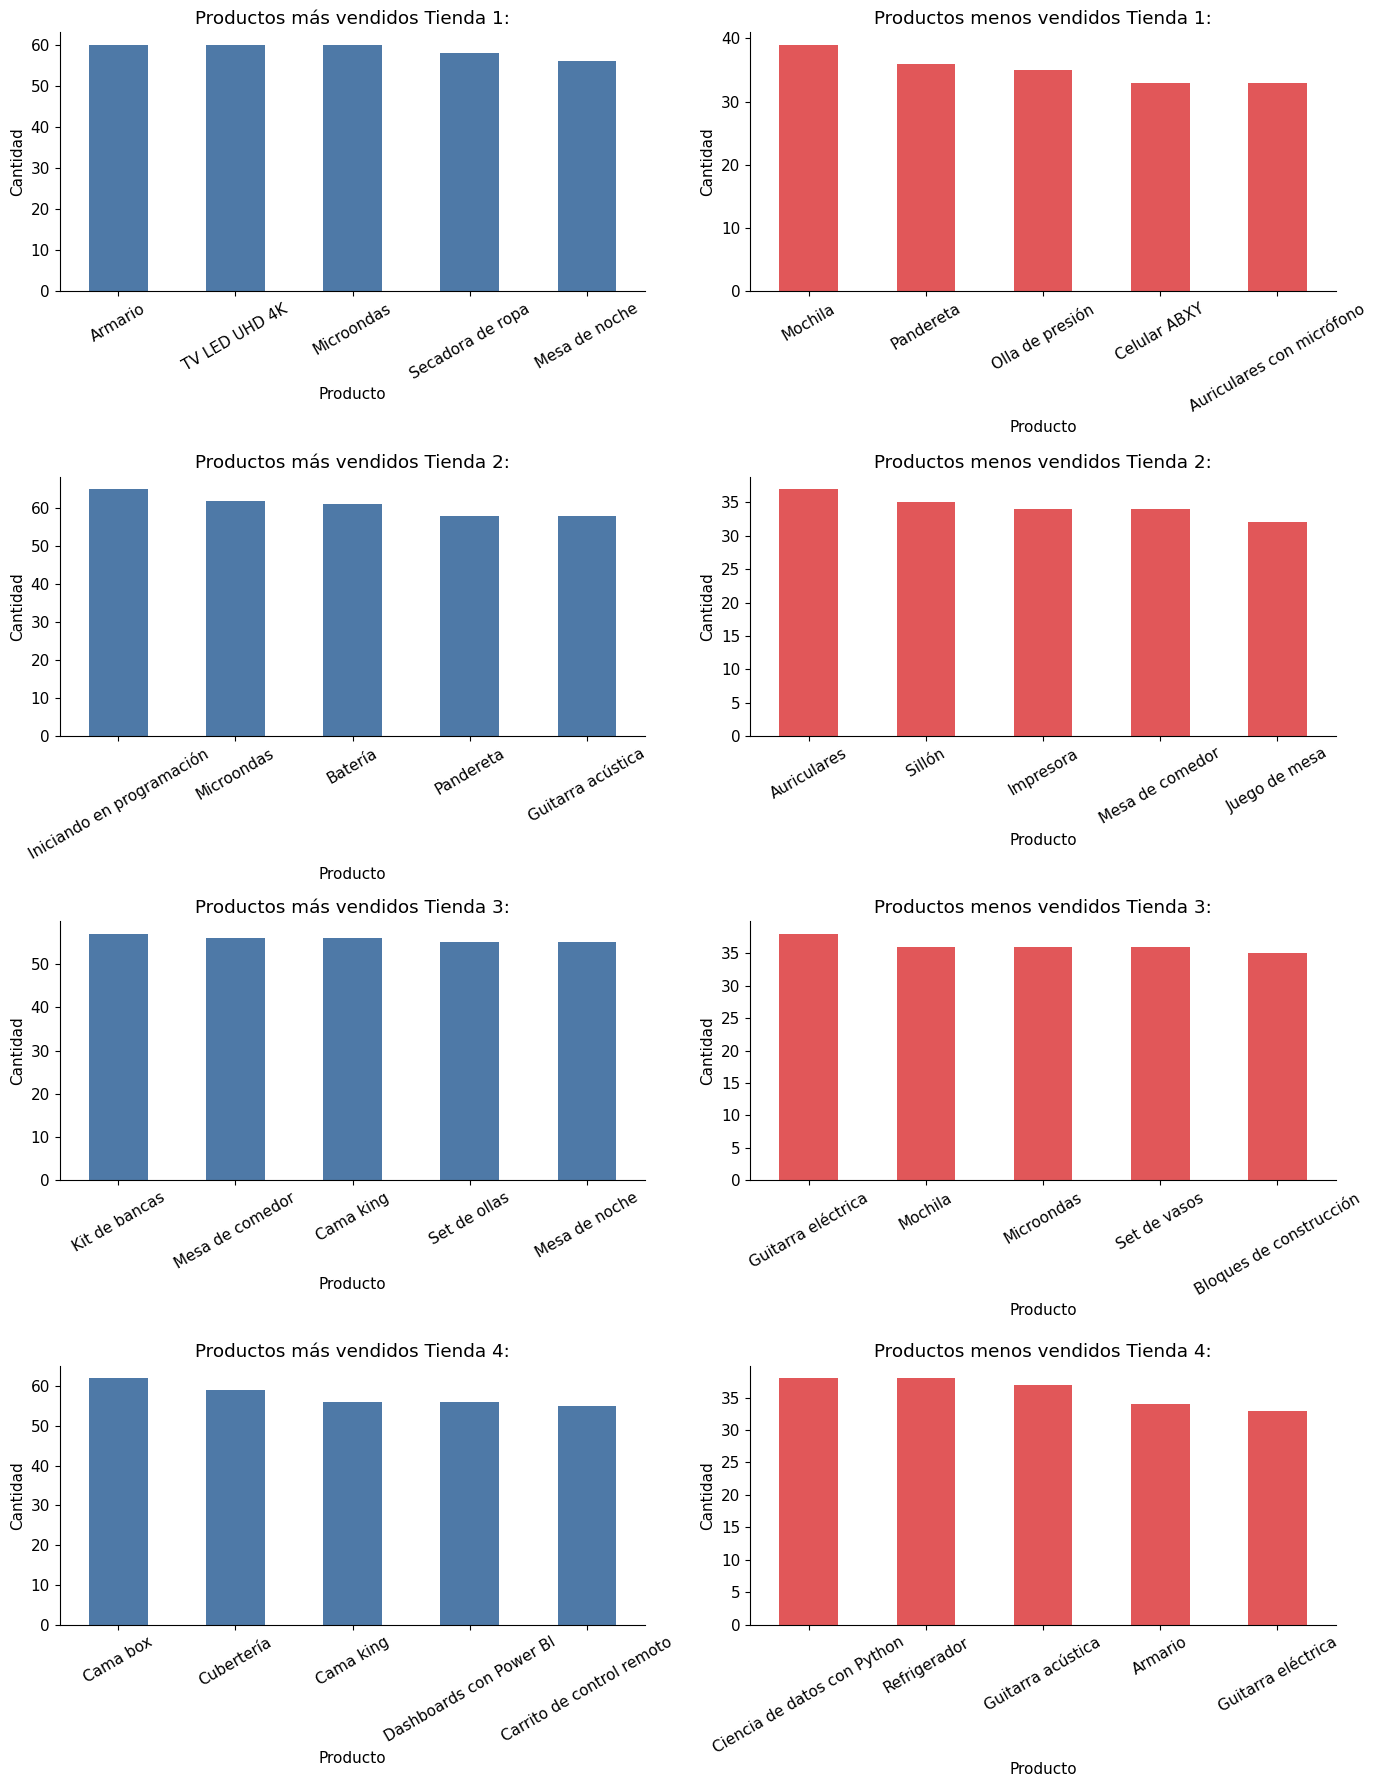

In [13]:
fig, axes = plt.subplots(4, 2, figsize=(14, 18))

for row, (name, df) in enumerate(tiendas.items()):
    ranking = (
        df.groupby("Producto")["Producto"]
        .count()
        .sort_values(ascending=False)
    )

    ranking.head().plot.bar(ax=axes[row, 0], color="#4e79a7")
    axes[row, 0].set_title(f"Productos más vendidos {name}:")
    axes[row, 0].set_ylabel("Cantidad")
    axes[row, 0].tick_params(axis="x", rotation=30)

    ranking.tail().plot.bar(ax=axes[row, 1], color="#e15759")
    axes[row, 1].set_title(f"Productos menos vendidos {name}:")
    axes[row, 1].set_ylabel("Cantidad")
    axes[row, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---
## 5. Costo de Envío Promedio por Tienda

In [15]:
costos = {name: df["Costo de envío"].mean() for name, df in tiendas.items()}

for name, costo in costos.items():
    print(f"Costo del envío promedio {name}: ${costo:.2f}")

Costo del envío promedio Tienda 1: $26018.61
Costo del envío promedio Tienda 2: $25216.24
Costo del envío promedio Tienda 3: $24805.68
Costo del envío promedio Tienda 4: $23459.46


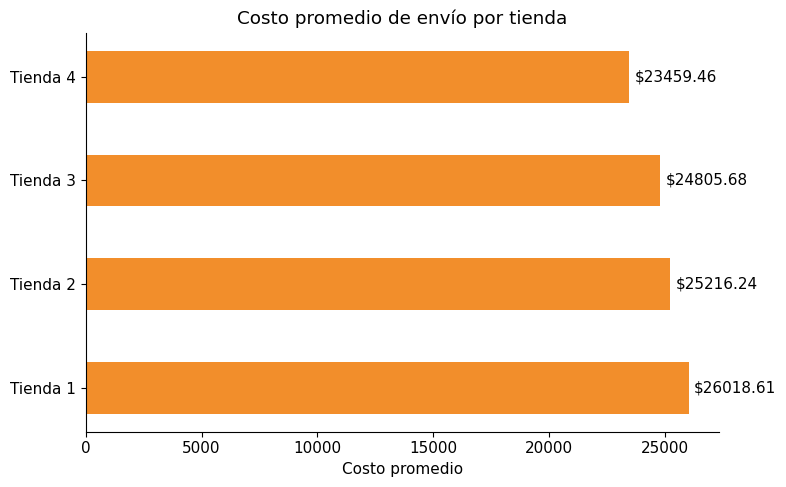

In [16]:
fig, ax = plt.subplots()

bars = ax.barh(list(costos.keys()), list(costos.values()), color="#f28e2b", height=0.5)
ax.bar_label(bars, fmt="$%.2f", padding=4)
ax.set_xlabel("Costo promedio")
ax.set_title("Costo promedio de envío por tienda")
plt.tight_layout()
plt.show()

## 6. Análisis

### Introducción

El presente informe tiene como propósito evaluar el desempeño de las cuatro tiendas del Sr. Juan, con el fin de determinar cuál de ellas sería la mejor opción para vender. Para ello, se analizaron distintos indicadores clave de negocio, entre ellos los ingresos totales, las categorías de productos con mayor y menor volumen de ventas, los productos más y menos vendidos, las calificaciones promedio otorgadas por los clientes y el coste de envío promedio de cada tienda.

---

### Desarrollo del análisis

#### 1. Ingresos totales de las tiendas

El análisis de los ingresos muestra que la **Tienda 1** registra la mayor participación en ventas, con aproximadamente **26.1%** del total consolidado. Muy cerca de ella se encuentran la **Tienda 2** y la **Tienda 3**, con niveles de ingresos similares. En contraste, la **Tienda 4** presenta la menor participación, con cerca de **23.6%**.

Aunque la diferencia porcentual entre las tiendas no es extremadamente amplia, sí permite observar que la Tienda 4 tiene un menor aporte relativo al resultado global del negocio, lo que constituye un primer indicador de menor fortaleza comercial frente a las demás.

#### 2. Categorías de productos más y menos vendidas

En términos generales, en las cuatro tiendas se repite una tendencia similar: las categorías de **Muebles** y **Electrónicos** son las más vendidas, consolidándose como las líneas más fuertes del negocio. Dentro de este comportamiento destaca especialmente la **Tienda 3**, que presenta el mejor desempeño en la categoría de **Muebles**, con **499 ventas**, además de un resultado también sobresaliente en **Electrónicos**, con **451 ventas**.

Por el contrario, las categorías con menor nivel de rotación corresponden principalmente a **Instrumentos musicales**, **Libros** y **Artículos para el hogar**. Aun así, la **Tienda 2** se diferencia ligeramente al mostrar un mejor desempeño relativo en **Instrumentos musicales**, con **224 ventas**, en comparación con las demás tiendas.

Este comportamiento evidencia que la Tienda 3 tiene una posición más sólida en las categorías estratégicas de mayor demanda, mientras que la Tienda 4 no sobresale de forma importante en ninguna de ellas.

#### 3. Calificaciones promedio de los clientes por tienda

La satisfacción del cliente es otro factor importante en la evaluación. En este indicador, la **Tienda 3** obtiene la mejor calificación promedio, con **4.05**, seguida muy de cerca por la **Tienda 2**, con **4.04**. La **Tienda 4** alcanza una valoración de **4.00**, mientras que la **Tienda 1** registra la calificación más baja, con **3.98**.

Aunque las diferencias entre las puntuaciones no son grandes, la Tienda 3 muestra una ligera ventaja en experiencia del cliente, lo que puede traducirse en mejores niveles de fidelización y sostenibilidad comercial a largo plazo. La Tienda 4, aunque no presenta una mala calificación, tampoco lidera este indicador.

#### 4. Productos más y menos vendidos

El análisis de productos permite identificar cuáles referencias impulsan realmente el rendimiento de cada tienda. En las visualizaciones realizadas se observa que existen productos con alta concentración de ventas, especialmente dentro de las categorías de **Muebles** y **Electrónicos**, mientras que ciertos productos de categorías como **Libros** o **Artículos para el hogar** presentan una menor rotación.

Esto confirma que el desempeño de cada tienda depende en gran medida de su capacidad para mover productos estratégicos de alta demanda. En este sentido, las tiendas con mejor dinamismo comercial son aquellas que logran sostener mayores ventas en los productos líderes. La **Tienda 4**, al tener un menor peso relativo en ingresos y no destacar en los productos más demandados, muestra una posición comparativamente menos competitiva.

#### 5. Coste de envío promedio por tienda

En cuanto a los costes logísticos, la **Tienda 1** presenta el coste de envío promedio más alto. Luego se ubican la **Tienda 2** y la **Tienda 3**, mientras que la **Tienda 4** registra el coste promedio más bajo entre todas.

Este resultado puede interpretarse como una ventaja operativa para la Tienda 4, ya sea por mayor eficiencia logística o por una estructura de distribución menos costosa. Sin embargo, aunque este factor es positivo, no resulta suficiente para compensar su menor desempeño en variables más determinantes como los ingresos y la fortaleza comercial en las categorías principales.

---

### Conclusión y recomendación

Con base en el análisis integral de los ingresos, las categorías más y menos vendidas, los productos con mayor y menor rotación, las calificaciones de los clientes y los costes de envío, se recomienda que el Sr. Juan considere vender la **Tienda 4**.

La principal razón de esta decisión es que la Tienda 4 presenta el **menor aporte en ingresos totales**, no sobresale en las **categorías estratégicas de mayor venta** y mantiene un desempeño general más discreto frente a las otras tiendas. Si bien su **coste de envío promedio es el más bajo**, esta fortaleza aislada no compensa su menor contribución al resultado global del negocio.

En contraste, la **Tienda 3** muestra un perfil más sólido y competitivo, ya que combina un buen nivel de ingresos, liderazgo en categorías clave como Muebles y Electrónicos, y la mejor calificación promedio de los clientes. La **Tienda 2** también mantiene un desempeño estable y competitivo, mientras que la **Tienda 1** conserva la mayor participación en ingresos, a pesar de tener mayores costes logísticos y una valoración ligeramente inferior por parte de los clientes.

En conclusión, vender la **Tienda 4** permitiría al Sr. Juan concentrar sus recursos en las tiendas con mejor desempeño general, mayor potencial de crecimiento y mejores condiciones competitivas a largo plazo.